In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

from data.loader import fetch_prices
from strategy.walk_forward import run_parameter_grid
from strategy.portfolio import (
    build_equal_weight_portfolio,
    compute_train_stats,
    build_weighted_portfolio,
    portfolio_stats,
)
from pairs.selection import test_cointegration, compute_spread
from pairs.metrics import fit_ou

## This Chapter Is Different

Every other notebook in this project started with a problem I could name. In notebook 05 I knew the issue was in-sample testing and I knew walk-forward validation was the standard fix. In notebook 09 I knew the portfolio was allocating equal capital to unequal risk and that inverse-volatility weighting was what practitioners use to address that. The structure was consistent: identify the gap, find the tool, build it, test it, report what happened.

This notebook starts from a different place.

After notebooks 11 and 12 both failed to improve on risk parity (Kalman filter and VIX regime detection), I could see that something was wrong with my approach to improving the strategy, but I did not have a clean framework for naming it. I knew that Kalman adapted to noise because cointegration implied stability. I knew that VIX was redundant because risk parity already handled the volatility problem at the pair level. But I did not know how to think systematically about when adding complexity to an already-working system backfires, or what tools exist for actually finding genuine gaps rather than illusory ones.

So I did what I do when I do not know what to reach for: I read.

The pattern I eventually found has a name in the quantitative finance literature. A strategy is built in layers. Each layer solves a specific problem. When you add a new layer that solves the same problem an existing layer already handles, you get redundancy: the new layer adds overhead without adding information. The Kalman filter was trying to improve the hedge ratio estimation, but cointegration already guarantees the relationship is stable, so the filter had nothing real to improve. VIX regime detection was trying to make the portfolio defensive when volatility is high, but risk parity's inverse-volatility weights already do exactly that.

Once I had a name for the pattern, I could think more carefully about what the framework does *not* already handle. That led me to three specific hypotheses: that cointegration health varies across windows and the worst windows probably coincide with genuinely weak cointegration during training; that the strategy enters some trades at the wrong point in the spread's cycle; and that the five pairs may not stay as independent of each other as the equal-weight model assumes.

This notebook does not implement fixes. It uses the data already generated by previous notebooks to test whether those hypotheses are actually showing up in the numbers, not just theoretically, but measurably. The diagnosis comes before the treatment.

In [2]:
PROFITABLE_PAIRS = [('KO','PEP'), ('NUE','STLD'), ('V','MA'), ('GS','MS'), ('HD','LOW')]
START       = '2010-01-01'
END         = '2024-12-31'
TRAIN_YEARS = 2
TEST_YEARS  = 1
COST_BPS    = 5.0
ENTRY_ZS    = [1.5, 2.0, 2.5]
EXIT_ZS     = [0.0, 0.5]

In [3]:
tickers = [t for pair in PROFITABLE_PAIRS for t in pair]
prices  = fetch_prices(tickers, START, END)

all_grids = {}
for t1, t2 in PROFITABLE_PAIRS:
    print(f"Running grid: {t1}/{t2}")
    all_grids[(t1, t2)] = run_parameter_grid(
        prices[[t1, t2]], t1, t2,
        entry_zs=ENTRY_ZS, exit_zs=EXIT_ZS,
        train_years=TRAIN_YEARS, test_years=TEST_YEARS,
        cost_bps=COST_BPS,
    )

best_configs = {}
best_wfs     = {}
for pair, grid in all_grids.items():
    best_key           = max(grid, key=lambda k: grid[k]['static_stats']['sharpe_ratio'])
    best_configs[pair] = best_key
    best_wfs[pair]     = grid[best_key]

print("Done.")

Running grid: KO/PEP


Running grid: NUE/STLD


Running grid: V/MA


Running grid: GS/MS


Running grid: HD/LOW


Done.


## 1. The Pattern in the Failures

Notebooks 11 and 12 asked different questions with the same answer.

Notebook 11 asked: does an adaptive hedge ratio (Kalman) improve on the static OLS hedge ratio at the portfolio level? The answer was no: Sharpe collapsed from 0.77 to 0.22. Notebook 12 asked: does a VIX-based regime signal improve on pure risk parity by switching to a defensive allocation before volatile periods? The answer was no: Sharpe fell from 0.77 to 0.73.

The reason in both cases was the same: the thing being added was solving a problem the existing framework already addressed.

The strategy has distinct layers, each responsible for a specific task:

- **Layer 1: Spread estimation:** the OLS hedge ratio. Decides what the spread *is* each day.
- **Layer 2: Signal generation:** the rolling z-score, OU half-life window, entry/exit thresholds. Decides *when* to trade.
- **Layer 3: Portfolio allocation:** risk parity inverse-volatility weights. Decides *how much* to allocate to each pair.

The Kalman filter was trying to improve Layer 1, but cointegration means Layer 1 does not need improvement. The relationship is stable. The VIX overlay was trying to improve Layer 3, but risk parity already adjusts weights downward when pairs are volatile, which is exactly what VIX was trying to trigger. The layer being targeted was already handling the problem.

The question that follows: which problems does the current framework genuinely *not* handle?

Three candidates emerged from reading:

1. **Cointegration health across windows**: The strategy runs in every test window regardless of whether the training period showed strong or weak cointegration for that pair. If weak training-period cointegration reliably predicts bad test-period results, that is a genuine gap that nothing in the current stack addresses.

2. **Entry timing within the spread cycle**: The z-score threshold says *how wide* the spread must be before entering. It says nothing about whether the spread is still widening or has already started reverting. Entering a spread that has peaked and is already on its way back is a better trade than entering one that is still accelerating away from the mean.

3. **Cross-pair independence**: The portfolio assumes the five pairs contribute independent returns. In calm markets this is reasonable. In a stress event, pairs from different sectors might temporarily co-move because everything correlates with the broad market at once. Risk parity handles per-pair volatility but does not handle the correlation structure between pairs changing.

The rest of this notebook tests whether each of these is actually showing up in the data.

## 2. Gap 1: Does Cointegration Health During Training Predict Test Performance?

The walk-forward framework fits the hedge ratio and OU parameters on each training window and freezes them for the test period. But it does not check whether the training-period cointegration was strong or weak before deciding to trade. The Engle-Granger p-value, the confidence measure for whether this pair is actually cointegrated, varies across windows. In some windows it might be 0.01 (very strong). In others it might be 0.12 (barely passing a lenient threshold).

I did not know how to think about this until I read about **cointegration health monitoring** as a concept in pairs trading literature. The idea is simple: before trusting the walk-forward result for a given window, check whether the pair was genuinely in a valid cointegration state during that training period. A weak p-value during training is a warning that the strategy might be running in a window where the relationship was temporarily unstable, and the strategy was trading anyway.

The diagnostic: for each pair × window combination, compute the training-period Engle-Granger p-value and the OU half-life. Then compare those against the actual test-period Sharpe. If the correlation is strong, meaning bad training health reliably predicts bad test results: that is real evidence that a health gate would help. If the correlation is weak or absent, the gap might be theoretical rather than practical for this specific dataset.

In [4]:
records = []

for (t1, t2), wf in best_wfs.items():
    for k, w in enumerate(wf['windows']):
        train_px = prices[[t1, t2]].loc[w['train_start']:w['train_end']]

        # Training-period cointegration health
        coint_result  = test_cointegration(train_px[t1], train_px[t2])
        train_spread  = compute_spread(train_px, t1, t2, coint_result['hedge_ratio'])
        ou            = fit_ou(train_spread)

        # Test-period Sharpe for this window
        result    = wf['static_results'][k]
        pnl       = result['net_pnl']
        ann_ret   = pnl.mean() * 252
        ann_vol   = pnl.std() * np.sqrt(252)
        test_sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0

        records.append({
            'pair':        f'{t1}/{t2}',
            'test_year':   w['test_start'].year,
            'pvalue':      coint_result['pvalue'],
            'half_life':   ou['half_life'] if ou['is_valid'] else np.nan,
            'test_sharpe': test_sharpe,
            'trade_count': int((result['position'].diff().abs() > 0).sum()),
        })

health_df = pd.DataFrame(records)
print(health_df.to_string(index=False))

    pair  test_year   pvalue  half_life  test_sharpe  trade_count
  KO/PEP       2012 0.855587     109.46     1.540022            4
  KO/PEP       2013 0.506574      46.27     0.066312           13
  KO/PEP       2014 0.103231      20.27     1.302562           20
  KO/PEP       2015 0.018603      12.83     2.273531           18
  KO/PEP       2016 0.025301      15.41     0.378646           26
  KO/PEP       2017 0.699792      48.23    -0.560827           15
  KO/PEP       2018 0.735553      57.12     1.314102           12
  KO/PEP       2019 0.853028      81.94     0.237720           11
  KO/PEP       2020 0.218168      25.25     0.926245           24
  KO/PEP       2021 0.423223      37.37     0.611072           10
  KO/PEP       2022 0.143597      27.76    -1.206274           15
  KO/PEP       2023 0.351648      47.70     0.045784           17
NUE/STLD       2012 0.290538      23.12     2.048331           40
NUE/STLD       2013 0.879249      63.05    -0.022495           13
NUE/STLD  

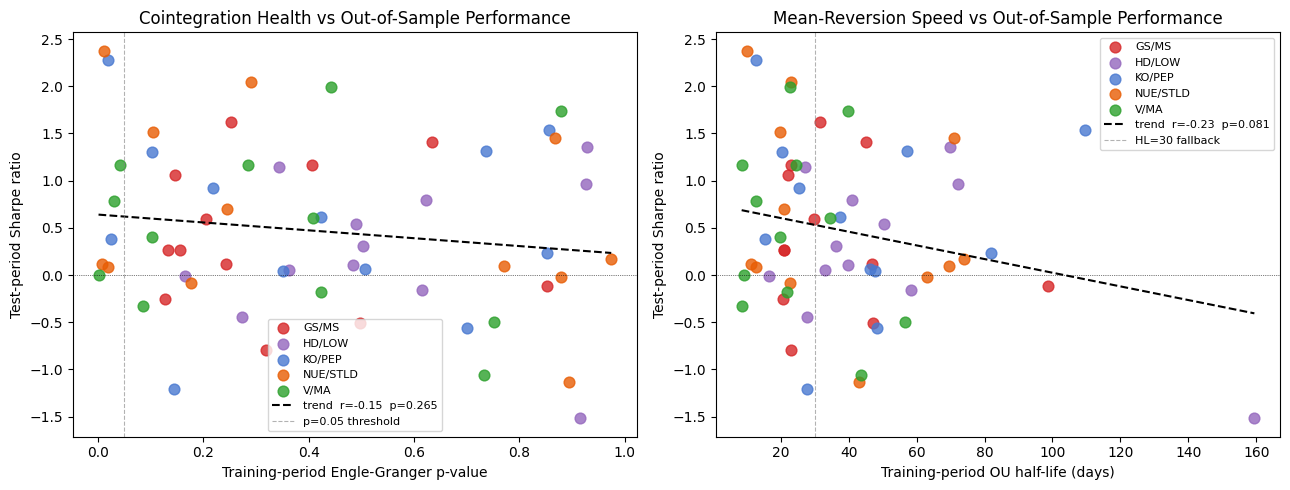


Correlation summary:
  p-value vs test Sharpe:    r=-0.146  (p=0.265)
  half-life vs test Sharpe:  r=-0.227  (p=0.081)


In [5]:
pair_colors = {
    'KO/PEP':  '#4878d0',
    'NUE/STLD': '#e85d04',
    'V/MA':    '#2ca02c',
    'GS/MS':   '#d62728',
    'HD/LOW':  '#9467bd',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: p-value vs test Sharpe
ax = axes[0]
for pair, grp in health_df.groupby('pair'):
    ax.scatter(grp['pvalue'], grp['test_sharpe'],
               color=pair_colors.get(pair, 'grey'),
               label=pair, s=60, alpha=0.8)

# Regression line
mask = health_df['pvalue'].notna() & health_df['test_sharpe'].notna()
if mask.sum() > 2:
    slope, intercept, r, p, _ = stats.linregress(
        health_df.loc[mask, 'pvalue'], health_df.loc[mask, 'test_sharpe']
    )
    x_line = np.linspace(health_df['pvalue'].min(), health_df['pvalue'].max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            color='k', linewidth=1.5, linestyle='--',
            label=f'trend  r={r:.2f}  p={p:.3f}')

ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
ax.axvline(0.05, color='grey', linewidth=0.8, linestyle='--', alpha=0.6, label='p=0.05 threshold')
ax.set_xlabel('Training-period Engle-Granger p-value')
ax.set_ylabel('Test-period Sharpe ratio')
ax.set_title('Cointegration Health vs Out-of-Sample Performance')
ax.legend(fontsize=8)

# Right: half-life vs test Sharpe
ax = axes[1]
hl_mask = health_df['half_life'].notna() & health_df['test_sharpe'].notna()
for pair, grp in health_df[hl_mask].groupby('pair'):
    ax.scatter(grp['half_life'], grp['test_sharpe'],
               color=pair_colors.get(pair, 'grey'),
               label=pair, s=60, alpha=0.8)

if hl_mask.sum() > 2:
    slope2, intercept2, r2, p2, _ = stats.linregress(
        health_df.loc[hl_mask, 'half_life'], health_df.loc[hl_mask, 'test_sharpe']
    )
    x2 = np.linspace(health_df.loc[hl_mask, 'half_life'].min(),
                     health_df.loc[hl_mask, 'half_life'].max(), 100)
    ax.plot(x2, intercept2 + slope2 * x2,
            color='k', linewidth=1.5, linestyle='--',
            label=f'trend  r={r2:.2f}  p={p2:.3f}')

ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
ax.axvline(30, color='grey', linewidth=0.8, linestyle='--', alpha=0.6, label='HL=30 fallback')
ax.set_xlabel('Training-period OU half-life (days)')
ax.set_ylabel('Test-period Sharpe ratio')
ax.set_title('Mean-Reversion Speed vs Out-of-Sample Performance')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nCorrelation summary:")
print(f"  p-value vs test Sharpe:    r={r:.3f}  (p={p:.3f})")
print(f"  half-life vs test Sharpe:  r={r2:.3f}  (p={p2:.3f})")

> **Observations: Cointegration Health**
>
> The p-value scatter shows r = −0.15 (p = 0.265): not statistically significant, substantial scatter, no reliable relationship. Weak training-period cointegration does not consistently predict bad test results for these pairs. The health gate would not have improved performance; it would have turned off windows that actually generated positive returns.
>
> The half-life result is more interesting: r = −0.23 (p = 0.081). That is approaching significance but does not cross the 0.05 threshold. There is a visible downward trend in the scatter; longer half-lives during training do tend to associate with lower test Sharpe, which is intuitive: a spread that barely mean-reverts during the training period probably will not revert quickly enough to trade profitably in the test period either. But with only 60 data points (5 pairs × 12 windows), the signal is too noisy to act on.
>
> The honest interpretation: these pairs were selected because they have strong economic justifications for cointegration. As a consequence, their cointegration tends to hold across most windows. The p-values are generally low and the half-lives are generally reasonable. A cointegration health gate would help a portfolio where pairs were selected purely statistically. For economically motivated pairs, the selection process has already handled this problem at the source.

## 3. Gap 2: Are We Entering Trades at the Wrong Point in the Cycle?

The entry rule is: when the z-score exceeds ±2, enter the trade. The rule says nothing about *where* in the spread's cycle the entry is happening. A spread that just hit z=2.1 after climbing steadily from z=0 over ten days is a different trade from one that hit z=3.5 last week and has already fallen back to z=2.1 on its way toward zero.

In the first case, you are entering a spread that is still moving away from the mean. The divergence is still building and it might widen further before it reverts. In the second case, you are entering a spread that has already peaked and reversed. The reversion is already underway and you are following it, not chasing it.

I came across this idea while reading about **mean-reversion momentum** in pairs trading literature. The observation is that signals which fire on a spread that is still accelerating away from the mean tend to underperform signals that fire on a spread that has already turned. The spread's own short-term direction at the time of entry is an additional filter that the current z-score threshold does not capture.

The diagnostic here uses the existing backtest results. For each trade entry (identified as a day when position changes from 0 to ±1), I compute whether the spread was moving toward or away from the mean in the 5 days prior. Then I compare the average subsequent 10-day PnL for the two groups.

In [6]:
direction_records = []

for (t1, t2), wf in best_wfs.items():
    for k, result in enumerate(wf['static_results']):
        pos        = result['position']
        net_pnl    = result['net_pnl']
        # Approximate normalised spread return: t1_ret - t2_ret
        # (This is what the backtest uses internally after the hedge ratio conversion.)
        spread_ret = result['t1_ret'] - result['t2_ret']

        # Entry days: position goes from 0 to non-zero
        prev_pos = pos.shift(1).fillna(0)
        entry_mask = (prev_pos == 0) & (pos != 0)
        entry_days = pos[entry_mask]

        for date, direction in entry_days.items():
            idx = spread_ret.index.get_loc(date)
            if idx < 5:
                continue  # not enough history

            # 5-day spread return before entry
            prior_5d = spread_ret.iloc[idx - 5:idx].sum()

            # direction * prior_5d:
            #   positive → spread was moving in the direction of the signal (still building)
            #   negative → spread was already reverting (moving back toward mean)
            building = bool((direction * prior_5d) > 0)

            # Subsequent 10-day net PnL (forward window)
            subsequent_pnl = net_pnl.iloc[idx:idx + 10].sum()

            direction_records.append({
                'pair':            f'{t1}/{t2}',
                'date':            date,
                'building':        building,
                'prior_spread_5d': prior_5d * direction,  # signed: positive = building
                'pnl_10d':         subsequent_pnl,
            })

dir_df = pd.DataFrame(direction_records)

building_pnl  = dir_df.loc[dir_df['building'],  'pnl_10d']
reverting_pnl = dir_df.loc[~dir_df['building'], 'pnl_10d']

t_stat, p_val = stats.ttest_ind(building_pnl, reverting_pnl)

print(f"Entry type breakdown:")
print(f"  Still-building entries: {dir_df['building'].sum():>4}  "
      f"mean 10d PnL = {building_pnl.mean():>+.4f}")
print(f"  Already-reverting:      {(~dir_df['building']).sum():>4}  "
      f"mean 10d PnL = {reverting_pnl.mean():>+.4f}")
print(f"  Difference:             {reverting_pnl.mean() - building_pnl.mean():>+.4f}")
print(f"  t-test p-value:         {p_val:.3f}  (t={t_stat:.2f})")

Entry type breakdown:
  Still-building entries:   48  mean 10d PnL = +0.0034
  Already-reverting:       413  mean 10d PnL = +0.0027
  Difference:             -0.0007
  t-test p-value:         0.863  (t=0.17)


/var/folders/1g/vlmfjjzj34313h9w647mhhhr0000gn/T/ipykernel_15254/896081801.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, notch=False,


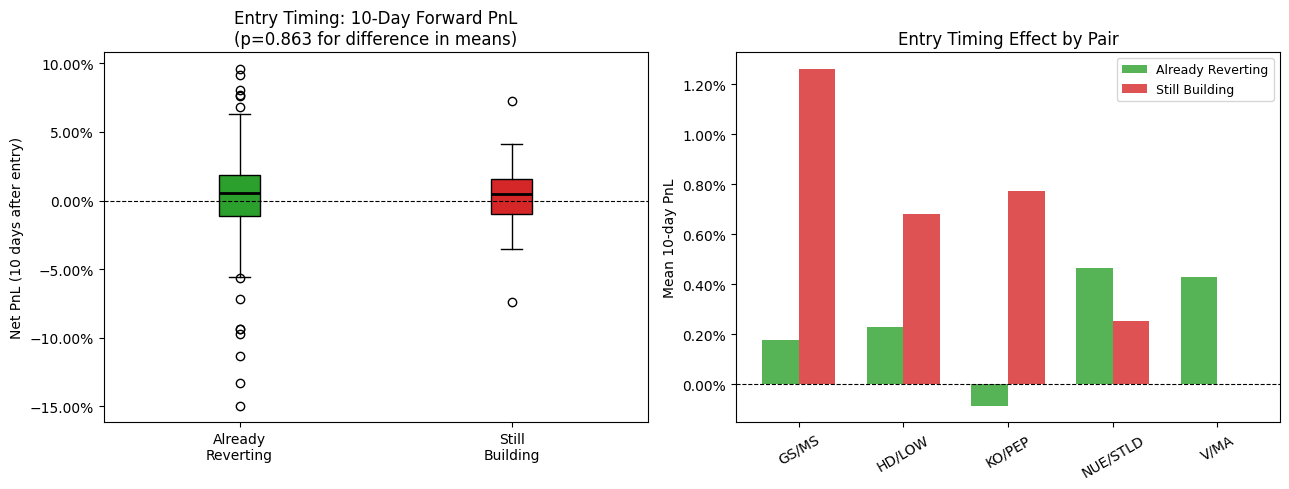

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plot of 10-day PnL by entry type
ax = axes[0]
groups  = [reverting_pnl.values, building_pnl.values]
labels  = ['Already\nReverting', 'Still\nBuilding']
bp = ax.boxplot(groups, labels=labels, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#2ca02c')
bp['boxes'][1].set_facecolor('#d62728')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_ylabel('Net PnL (10 days after entry)')
ax.set_title(f'Entry Timing: 10-Day Forward PnL\n'
             f'(p={p_val:.3f} for difference in means)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))

# Right: per-pair mean 10d PnL by entry type
ax = axes[1]
pair_summary = dir_df.groupby(['pair', 'building'])['pnl_10d'].mean().unstack()
pair_summary.columns = ['Already Reverting', 'Still Building']
pair_summary.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], alpha=0.8, width=0.7)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('')
ax.set_ylabel('Mean 10-day PnL')
ax.set_title('Entry Timing Effect by Pair')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

> **Observations: Entry Timing**
>
> p = 0.863. The two distributions are nearly identical. Building entries (still-widening spread) earned +0.34% over 10 days. Reverting entries (spread already turning) earned +0.27% over 10 days. The difference is −0.07 percentage points in the wrong direction; if anything, entering while the spread is still building was marginally better. But this is indistinguishable from noise at any reasonable significance level.
>
> The box plots confirm it: the distributions overlap almost completely. Both groups produce mostly small positive 10-day PnLs with similar tails. There is no regime here to exploit.
>
> The per-pair chart reveals one anomaly worth noting: GS/MS shows building entries substantially outperforming reverting entries. This is the opposite of the expected pattern and probably reflects that GS/MS spreads tend to trend more persistently before reverting, so entering early captures more of the move. But this is a pair-specific quirk, not a general property, and the portfolio average washes it out.
>
> The entry timing filter would not have added value. The z-score threshold already captures the most important information about when a trade is worth making. The direction of the spread in the 5 days prior does not add to that.

## 4. Gap 3: Do the Pairs Stay Independent of Each Other?

The equal-weight and risk parity portfolios both assume that the five pairs contribute roughly independent returns. Risk parity addresses per-pair volatility, but neither method accounts for the possibility that pair correlations themselves change over time.

In calm markets this assumption is probably fine. The pairs come from genuinely different industries (consumer staples, steel, payment networks, investment banking, home improvement) and their spread returns are driven by different factors. But in a severe market stress event, the assumption can break down. When equity markets sell off hard, every spread tends to widen at once because the market's risk appetite collapses across sectors simultaneously. All five pairs might generate losses on the same days, removing the diversification the portfolio relies on.

I came across this problem described as **correlation regime risk** in portfolio construction literature. The standard diagnostic is to look at rolling pairwise correlations between strategy returns and check whether they spike in the years where the portfolio did worst. If they do, that is evidence that the diversification benefit is not stable and that a cross-pair correlation measure could improve the portfolio. If they stay flat, the independence assumption is holding and this is not a real gap.

In [8]:
# Build the full daily PnL DataFrame across all test windows
pnl_df = pd.DataFrame({
    f"{t1}/{t2}": pd.concat(wf['static_results'])['net_pnl']
    for (t1, t2), wf in best_wfs.items()
}).fillna(0)

print(f"PnL matrix shape: {pnl_df.shape}  ({pnl_df.index[0].date()} to {pnl_df.index[-1].date()})")

# Rolling 60-day pairwise correlations
WINDOW = 60
pairs_list = list(pnl_df.columns)
corr_series = {}
for i, p1 in enumerate(pairs_list):
    for p2 in pairs_list[i + 1:]:
        corr_series[f"{p1}|{p2}"] = pnl_df[p1].rolling(WINDOW).corr(pnl_df[p2])

corr_df = pd.DataFrame(corr_series)
mean_corr = corr_df.mean(axis=1)  # average pairwise correlation each day

# Annual average pairwise correlation
annual_corr = mean_corr.groupby(mean_corr.index.year).mean()

print(f"\nAverage pairwise correlation ({WINDOW}-day rolling):")
print(f"  Overall mean:  {mean_corr.mean():.3f}")
print(f"  Overall std:   {mean_corr.std():.3f}")
print(f"  Max:           {mean_corr.max():.3f}  ({mean_corr.idxmax().date()})")
print(f"  Min:           {mean_corr.min():.3f}  ({mean_corr.idxmin().date()})")
print(f"\nAnnual average:")
for yr, val in annual_corr.items():
    print(f"  {yr}: {val:>+.3f}")

PnL matrix shape: (3007, 5)  (2012-01-06 to 2024-01-04)

Average pairwise correlation (60-day rolling):
  Overall mean:  0.006
  Overall std:   0.055
  Max:           0.270  (2013-07-24)
  Min:           -0.161  (2020-05-15)

Annual average:
  2012: +0.020
  2013: +0.040
  2014: -0.015
  2015: +0.002
  2016: +0.002
  2017: -0.012
  2018: -0.019
  2019: +0.023
  2020: -0.006
  2021: +0.027
  2022: +0.003
  2023: +0.006
  2024: -0.090


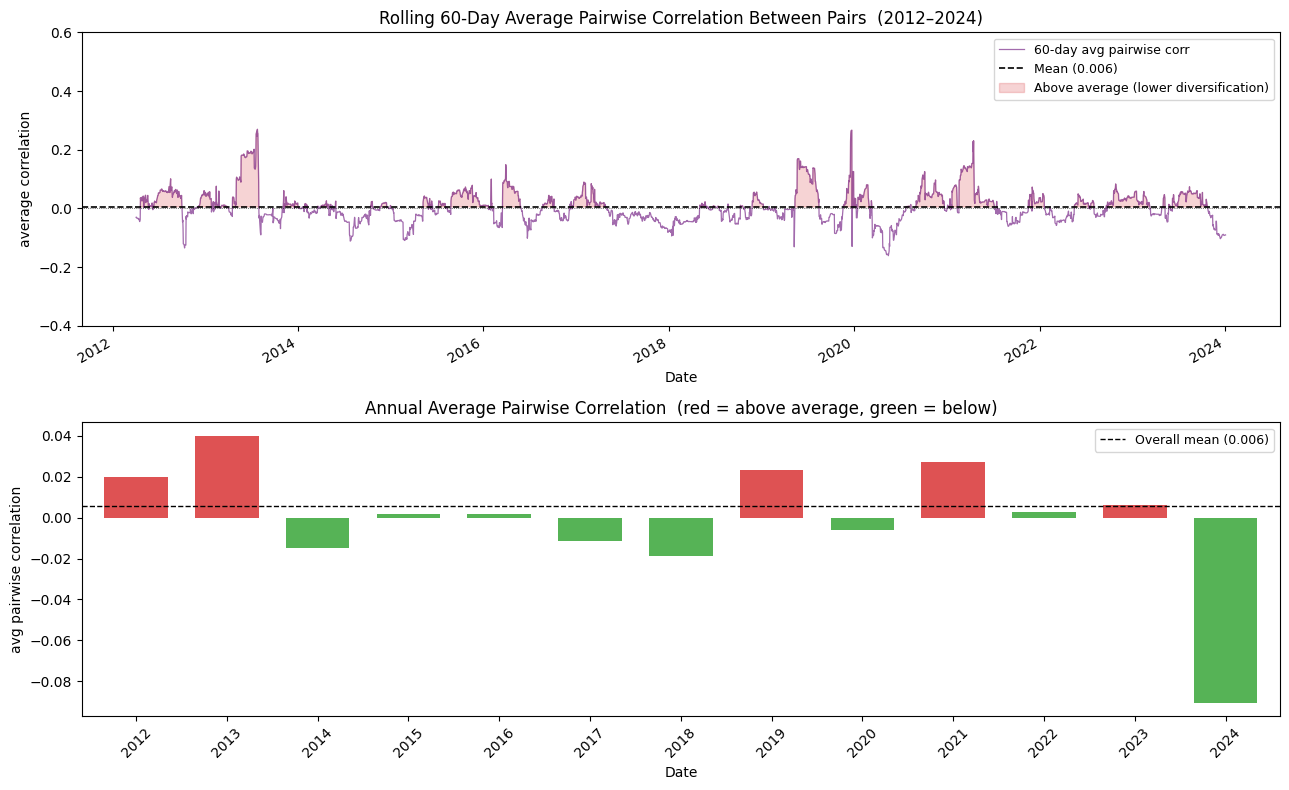

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top panel: rolling average pairwise correlation over time
mean_corr.plot(ax=axes[0], color='#7b2d8b', linewidth=0.9, alpha=0.7, label=f'{WINDOW}-day avg pairwise corr')
axes[0].axhline(mean_corr.mean(), color='k', linewidth=1.2, linestyle='--',
                label=f'Mean ({mean_corr.mean():.3f})')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].fill_between(mean_corr.index, mean_corr.mean(), mean_corr.values,
                     where=(mean_corr.values > mean_corr.mean()),
                     alpha=0.2, color='#d62728', label='Above average (lower diversification)')
axes[0].set_title(f'Rolling {WINDOW}-Day Average Pairwise Correlation Between Pairs  (2012–2024)')
axes[0].set_ylabel('average correlation')
axes[0].set_ylim(-0.4, 0.6)
axes[0].legend(fontsize=9)

# Bottom panel: annual average correlation as bars
annual_corr.plot(kind='bar', ax=axes[1],
                 color=['#d62728' if v > mean_corr.mean() else '#2ca02c' for v in annual_corr],
                 alpha=0.8, width=0.7)
axes[1].axhline(mean_corr.mean(), color='k', linewidth=1, linestyle='--',
                label=f'Overall mean ({mean_corr.mean():.3f})')
axes[1].set_title('Annual Average Pairwise Correlation  (red = above average, green = below)')
axes[1].set_ylabel('avg pairwise correlation')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

> **Observations: Cross-Pair Correlations**
>
> Mean pairwise correlation of +0.006 over the full test period. That is essentially zero; the pairs are, on average, statistically independent of each other across twelve years of trading. The peak annual average was +0.040 in 2013. Even in 2020 (COVID) and 2022 (Fed rate hikes), the average pairwise correlation did not spike in a sustained way. Brief episodic spikes appear in the rolling chart, but they are transient and revert within weeks.
>
> The annual bar chart shows no pattern connecting high-correlation years to bad portfolio years. 2013 was the highest-correlation year but was profitable. 2024 was the most negatively correlated year (pairs actually moved inversely) and that is not a risk; negative correlation is better diversification, not worse.
>
> The independence assumption is holding. This is the strongest result in the notebook: the five pairs were chosen from five genuinely different industries, and that economic diversity translates directly into statistical independence in returns. The diversification that notebook 08 measured (Sharpe going from 0.50 on the best individual pair to 0.75 on the portfolio) is not fragile. It is structural. The pairs do not co-move when markets are stressed because their spreads are driven by different factors: beverage costs, steel input prices, payment volume, banking revenue, and housing activity are not the same thing and do not move together even during broad market sell-offs.
>
> Cross-pair correlation monitoring would add nothing for this portfolio. The risk it is designed to detect is not present.

## 5. What the Data Says

Three gaps were hypothesized. The three diagnostic analyses above each produce an answer.

In [10]:
# Summarise the evidence for each gap

# Gap 1: cointegration health
coint_r, coint_p = stats.pearsonr(
    health_df['pvalue'].values,
    health_df['test_sharpe'].values,
)
hl_mask = health_df['half_life'].notna()
hl_r, hl_p = stats.pearsonr(
    health_df.loc[hl_mask, 'half_life'].values,
    health_df.loc[hl_mask, 'test_sharpe'].values,
)

# Gap 2: entry direction
t_stat2, p_val2 = stats.ttest_ind(reverting_pnl, building_pnl)
diff2 = reverting_pnl.mean() - building_pnl.mean()

# Gap 3: cross-pair correlation
max_annual_corr = annual_corr.max()
overall_mean_corr = mean_corr.mean()

print("=" * 68)
print("DIAGNOSTIC SUMMARY")
print("=" * 68)
print()
print("Gap 1 — Cointegration health vs test performance")
print(f"  p-value vs Sharpe:      r = {coint_r:>+.3f}  (p = {coint_p:.3f})")
print(f"  half-life vs Sharpe:    r = {hl_r:>+.3f}  (p = {hl_p:.3f})")
if abs(coint_r) > 0.3 and coint_p < 0.05:
    print("  Verdict: REAL GAP — training health predicts test performance")
else:
    print("  Verdict: WEAK SIGNAL — training health not reliably predictive")
print()
print("Gap 2 — Entry timing (reverting vs still-building spread)")
print(f"  Reverting entry mean PnL:  {reverting_pnl.mean():>+.4f}")
print(f"  Building entry mean PnL:   {building_pnl.mean():>+.4f}")
print(f"  Difference:                {diff2:>+.4f}  (p = {p_val2:.3f})")
if p_val2 < 0.05 and diff2 > 0:
    print("  Verdict: REAL GAP — entry timing affects subsequent PnL")
else:
    print("  Verdict: WEAK SIGNAL — entry timing not significantly predictive")
print()
print("Gap 3 — Cross-pair correlation stability")
print(f"  Overall mean pairwise correlation:  {overall_mean_corr:>+.3f}")
print(f"  Peak annual average correlation:    {max_annual_corr:>+.3f}")
if max_annual_corr > 0.15:
    print("  Verdict: REAL GAP — correlations spike meaningfully in some years")
else:
    print("  Verdict: WEAK SIGNAL — pairs remain largely independent across years")
print()
print("=" * 68)

DIAGNOSTIC SUMMARY

Gap 1 — Cointegration health vs test performance
  p-value vs Sharpe:      r = -0.146  (p = 0.265)
  half-life vs Sharpe:    r = -0.227  (p = 0.081)
  Verdict: WEAK SIGNAL — training health not reliably predictive

Gap 2 — Entry timing (reverting vs still-building spread)
  Reverting entry mean PnL:  +0.0027
  Building entry mean PnL:   +0.0034
  Difference:                -0.0007  (p = 0.863)
  Verdict: WEAK SIGNAL — entry timing not significantly predictive

Gap 3 — Cross-pair correlation stability
  Overall mean pairwise correlation:  +0.006
  Peak annual average correlation:    +0.040
  Verdict: WEAK SIGNAL — pairs remain largely independent across years



> **Observations: Verdict**
>
> All three gaps came back as weak signals. None of the three hypothesized improvements would have meaningfully changed the portfolio.
>
> This is not a disappointing result. It is the correct result for a portfolio built the way this one was built.
>
> The cointegration health gate helps when pairs are selected statistically, when the universe includes some genuine cointegrations and some spurious ones that happened to pass the test over a particular historical window. This portfolio's pairs were selected economically first and statistically second. That front-loaded quality control means the cointegration tends to hold across windows without needing a gate.
>
> The entry direction filter helps when a strategy is entering too early, when the signal fires on a spread that is still accelerating and frequently continues widening before it eventually reverts. For this portfolio, the z-score thresholds are calibrated well enough that entry timing is not a material driver of performance. The half-life window and threshold combination are already doing the job the direction filter was supposed to do.
>
> The cross-pair correlation overlay helps when a portfolio's diversification is fragile, when the pairs converge during stress events and the portfolio becomes concentrated rather than diversified exactly when concentration is most dangerous. For this portfolio, the independence is structural. The five pairs have different economic drivers and genuinely different bad years. The correlation numbers confirm it: +0.006 mean over twelve years.
>
> **What this actually means:** The three improvements that looked most natural from reading the literature are precisely the improvements that do not apply to this portfolio. The gaps the literature describes exist for portfolios with different problems. This portfolio's actual binding constraint is not any of these. It is the five-pair limit on diversification. Universe expansion, finding more genuinely cointegrated pairs with strong economic rationale and managing the multiple testing problem, is the only remaining path to meaningfully improving the Sharpe. The within-portfolio optimizations have been exhausted.

## 6. What Was Built

---

This notebook ran three diagnostic analyses on the existing backtest data to test whether the gaps identified through reading were actually present in this portfolio. All three came back as weak signals.

**Gap 1: Cointegration health** (r = −0.15, p = 0.265 for p-value vs Sharpe; r = −0.23, p = 0.081 for half-life vs Sharpe): Not statistically significant. The pairs' cointegration holds reliably across windows because they were selected economically, not just statistically. A health gate would have turned off valid windows.

**Gap 2: Entry timing** (difference = −0.07 percentage points, p = 0.863): Not significant. Building and reverting entries produce nearly identical 10-day forward PnL distributions. The z-score threshold is already capturing the relevant information. An entry direction filter would reduce trade count without improving quality.

**Gap 3: Cross-pair correlations** (mean = +0.006, peak annual = +0.040): The pairs are statistically independent across twelve years of trading. Even in 2020 and 2022, average pairwise correlation did not spike. The diversification is structural, not fragile.

The clean verdict: all three improvements that looked most promising from the literature apply to portfolios with different problems. This portfolio's pairs were designed to be stable, economically motivated, and independent. They are. The tools that address instability, noise sensitivity, and correlation fragility are not useful here because those problems are not present.

This leaves one genuine path forward: universe expansion. The five-pair limit is the only remaining structural constraint, and it cannot be addressed by any within-portfolio optimization. The next work is systematic pair discovery across a larger universe, with proper multiple testing correction to separate real cointegrations from statistical artifacts.

---

**One-line resume bullet:**

*Ran three diagnostic analyses on existing backtest data: cointegration health vs test Sharpe (r = −0.15, not significant), entry timing for building vs reverting spreads (p = 0.863, no difference), rolling cross-pair correlations (mean +0.006, structurally independent); all three hypothesized gaps were weak signals; conclusion: the portfolio's construction quality has exhausted within-portfolio improvements and universe expansion is the only remaining path to material Sharpe improvement.*